In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os


#read the data

# list files in dir
eval_rewards = {}
eval_stats = {}
for rfunc in ['v0','v1','v2']:
    rname = f'{rfunc}/rewards_{rfunc}.csv'
    sname = f'{rfunc}/coverage_{rfunc}.csv'
    rewards = pd.read_csv(os.path.join('evaluation_results', rname))
    stats = pd.read_csv(os.path.join('evaluation_results', sname))
    eval_rewards[rfunc] = rewards
    eval_stats[rfunc] = stats

train_rewards = {}
train_stats = {}
for rfunc in ['v0','v1','v2']:
    rname = f'{rfunc}/rewards_{rfunc}.csv'
    sname = f'{rfunc}/coverage_{rfunc}.csv'
    rewards = pd.read_csv(os.path.join('results', rname))
    stats = pd.read_csv(os.path.join('results', sname))
    train_rewards[rfunc] = rewards
    train_stats[rfunc] = stats




### Plotting train rewards

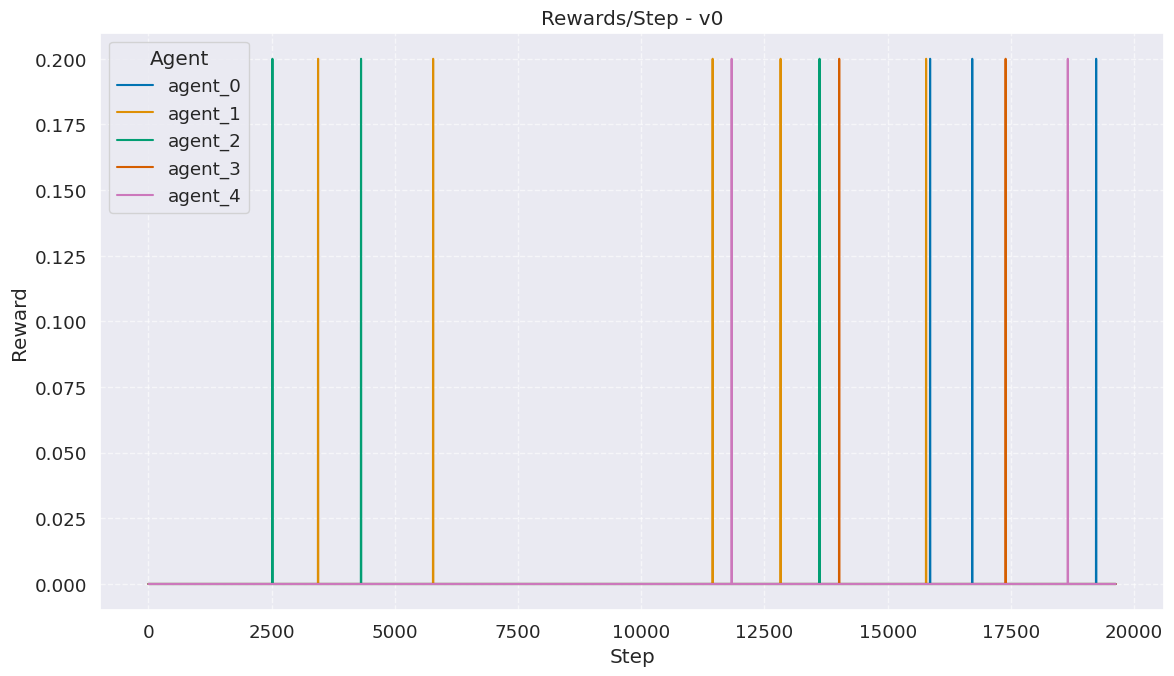

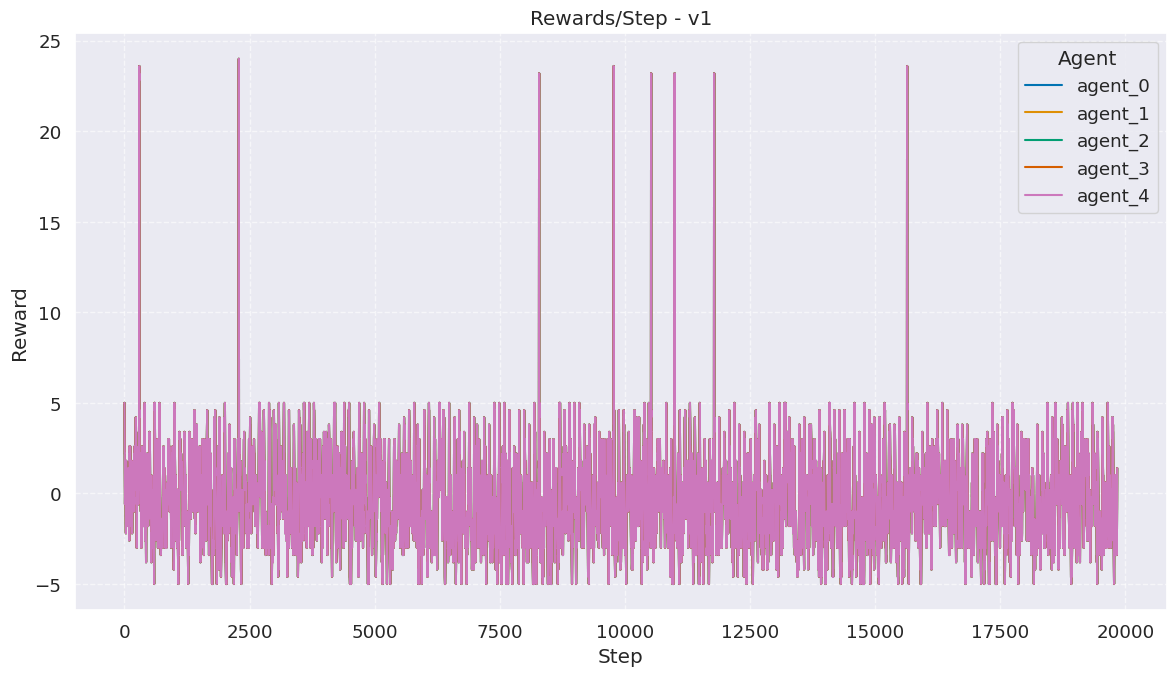

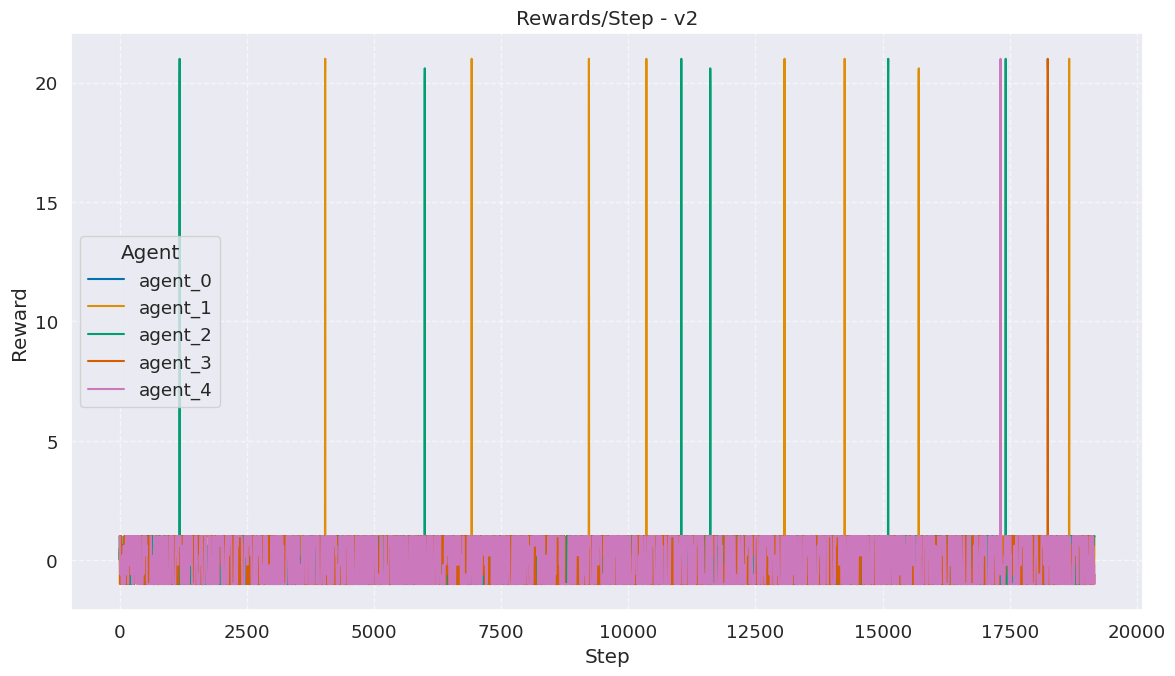

In [2]:
from plotting import plot_rewards
plot_rewards(train_rewards)

### Plotting train stats - AGENTS

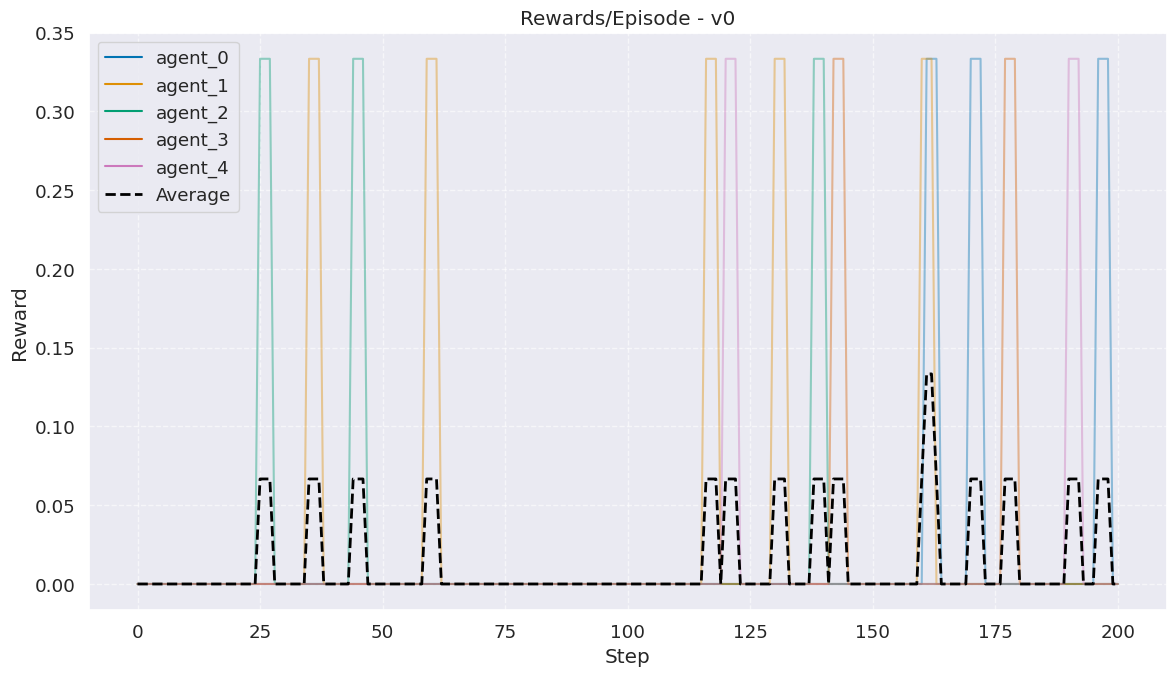

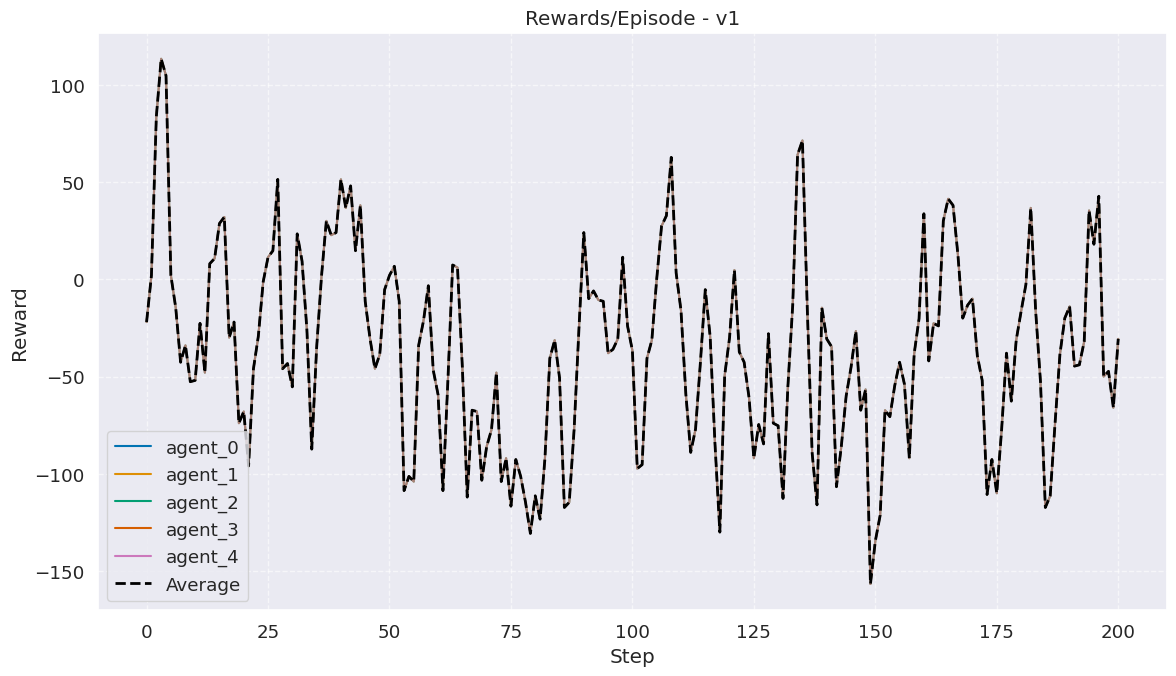

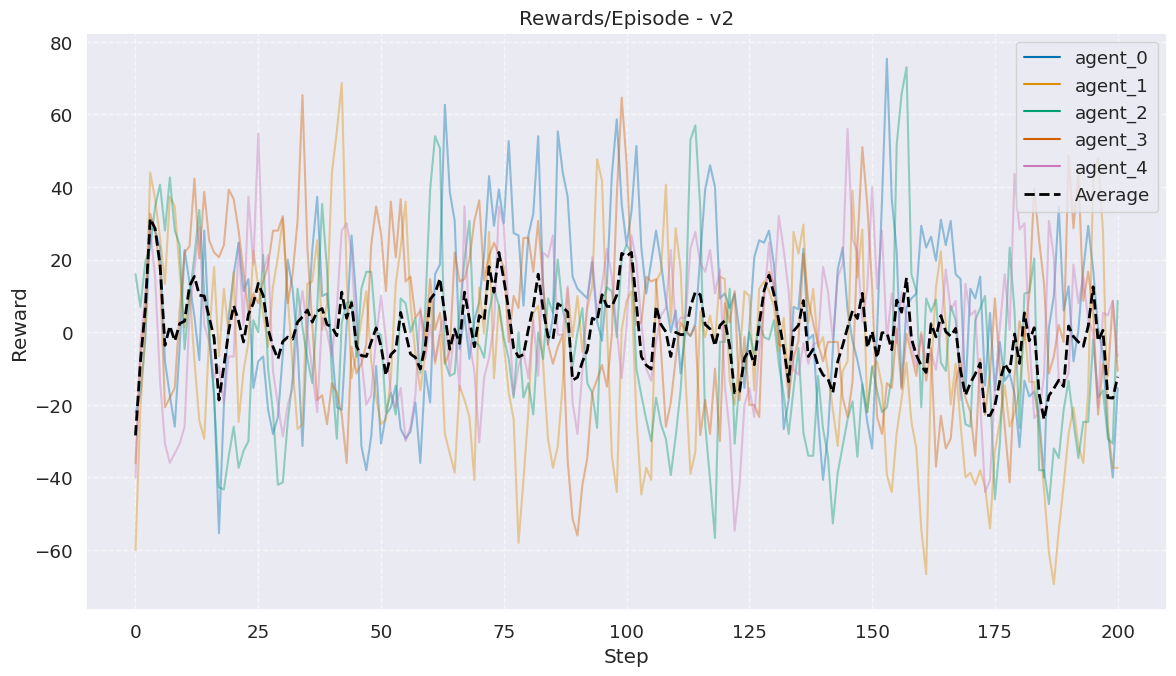

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotting import plot_stats

plot_stats(train_stats)


### Plotting train stats - Coverage and found


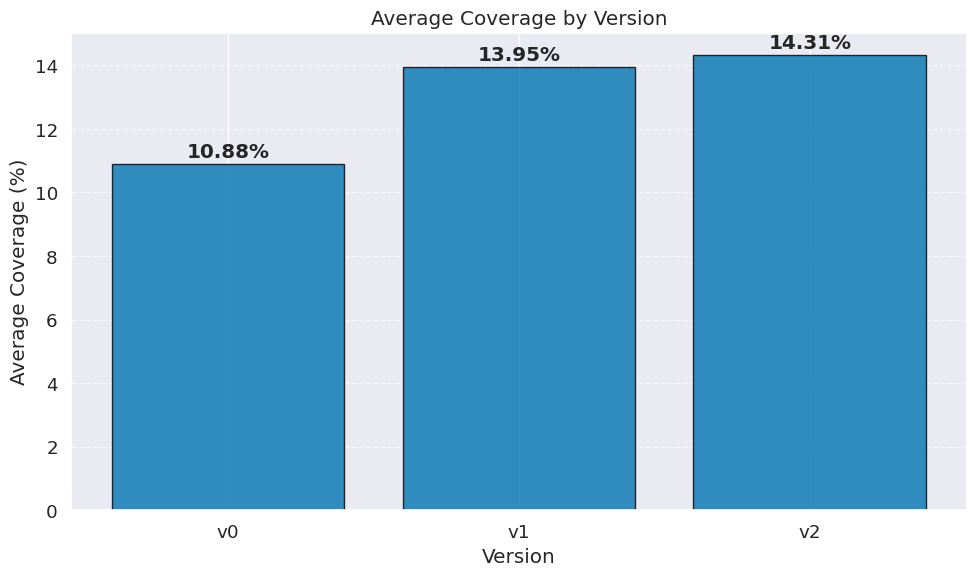

0
0
0


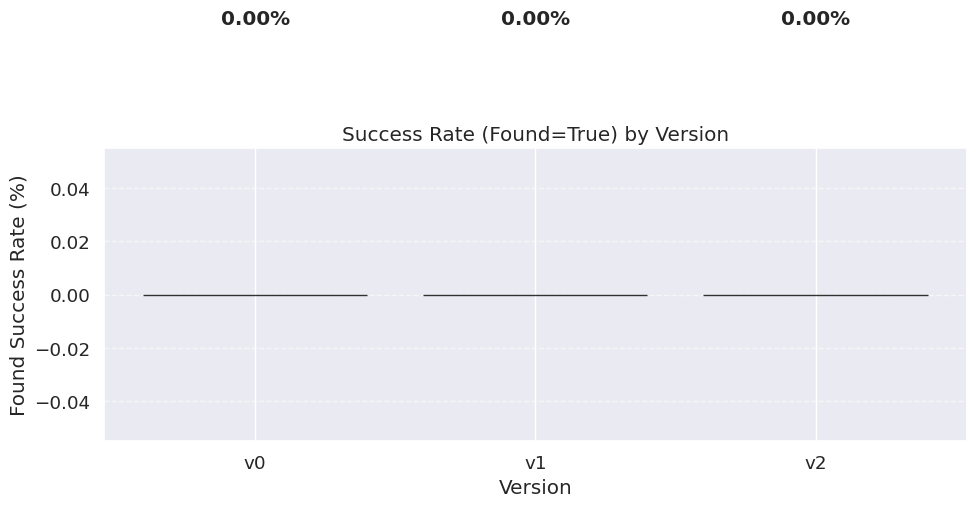

In [21]:
def plot_coverage(train_stats):
    sns.set_theme(style="darkgrid", palette="colorblind", font_scale=1.2)
    
    # Calculate average coverage for each version
    avg_coverage = {}
    for rfunc, df in train_stats.items():
        avg_coverage[rfunc] = df['coverage'].mean()
    
    # Create bar plot
    plt.figure(figsize=(10, 6))
    versions = list(avg_coverage.keys())
    values = list(avg_coverage.values())
    
    bars = plt.bar(versions, values, alpha=0.8, edgecolor='black', linewidth=1)
    
    # Add value labels on top of bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{value:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.xlabel('Version')
    plt.ylabel('Average Coverage (%)')
    plt.title('Average Coverage by Version')
    plt.grid(True, linestyle='--', alpha=0.6, axis='y')
    plt.tight_layout()
    plt.show()


def plot_found(train_stats):
    sns.set_theme(style="darkgrid", palette="colorblind", font_scale=1.2)
    
    # Calculate percentage of True values in 'found' column for each version
    found_percentage = {}
    for rfunc, df in train_stats.items():
        print(df['found'].sum())
        found_percentage[rfunc] = (df['found'].sum() / len(df)) * 100
    
    # Create bar plot
    plt.figure(figsize=(10, 6))
    versions = list(found_percentage.keys())
    values = list(found_percentage.values())
    
    bars = plt.bar(versions, values, alpha=0.8, edgecolor='black', linewidth=1, color='orange')
    
    # Add value labels on top of bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{value:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.xlabel('Version')
    plt.ylabel('Found Success Rate (%)')
    plt.title('Success Rate (Found=True) by Version')
    plt.grid(True, linestyle='--', alpha=0.6, axis='y')
    plt.tight_layout()
    plt.show()


plot_coverage(train_stats)
plot_found(train_stats)

### Plotting Evaluation Rewards

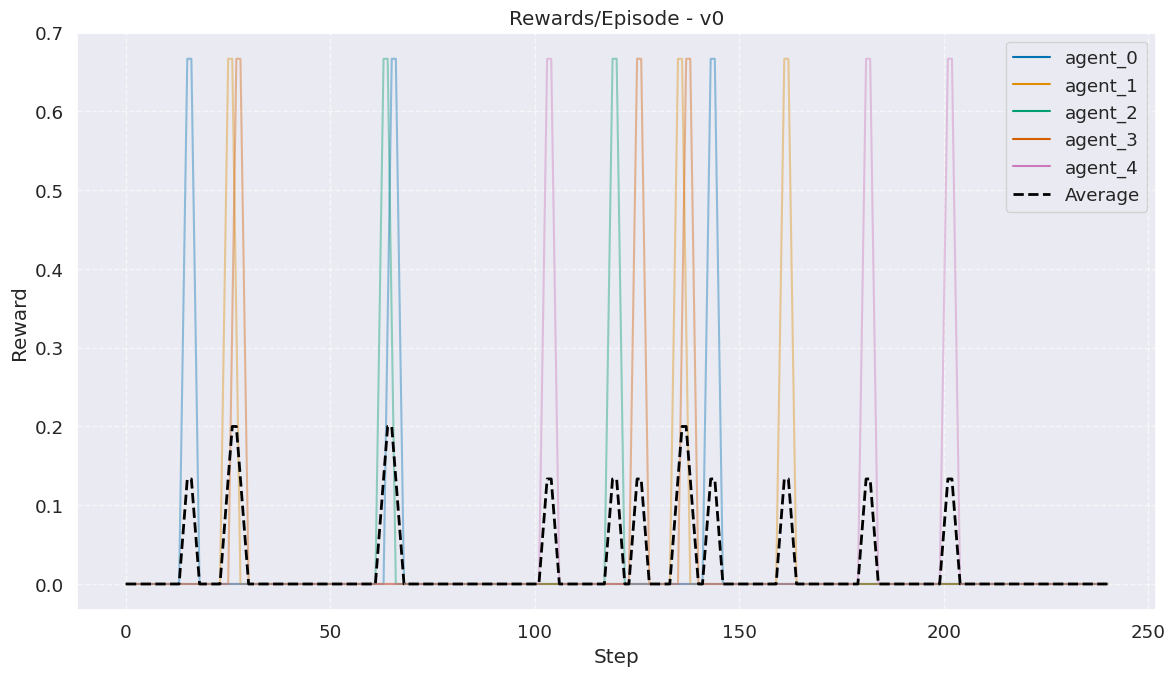

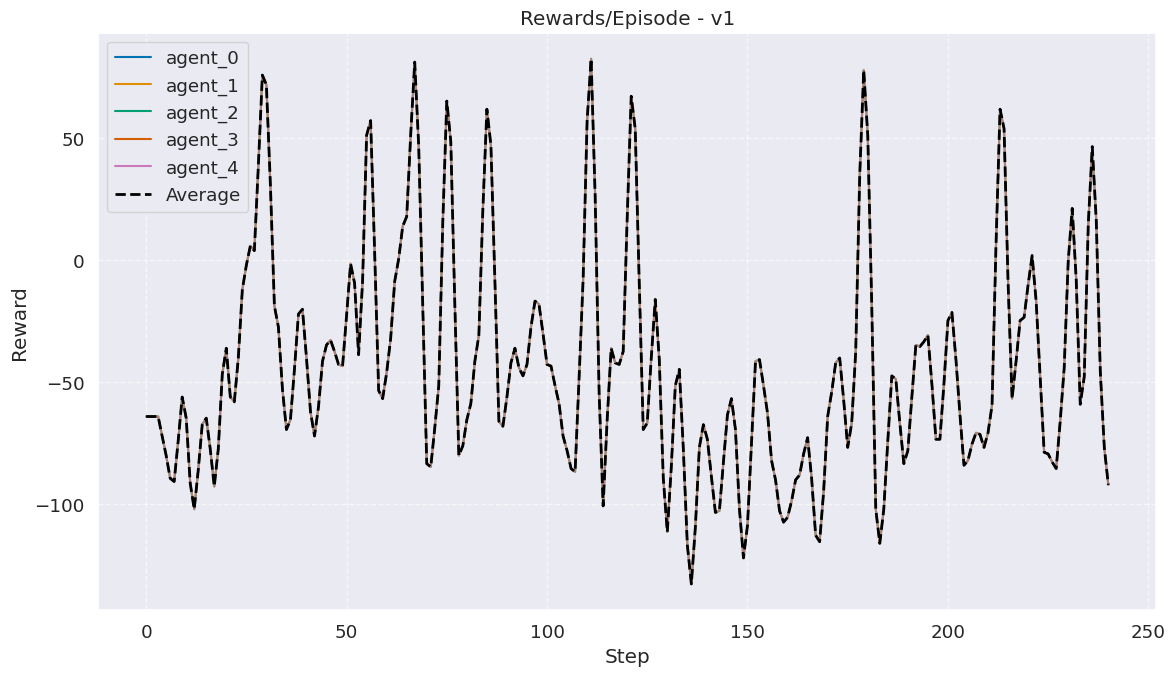

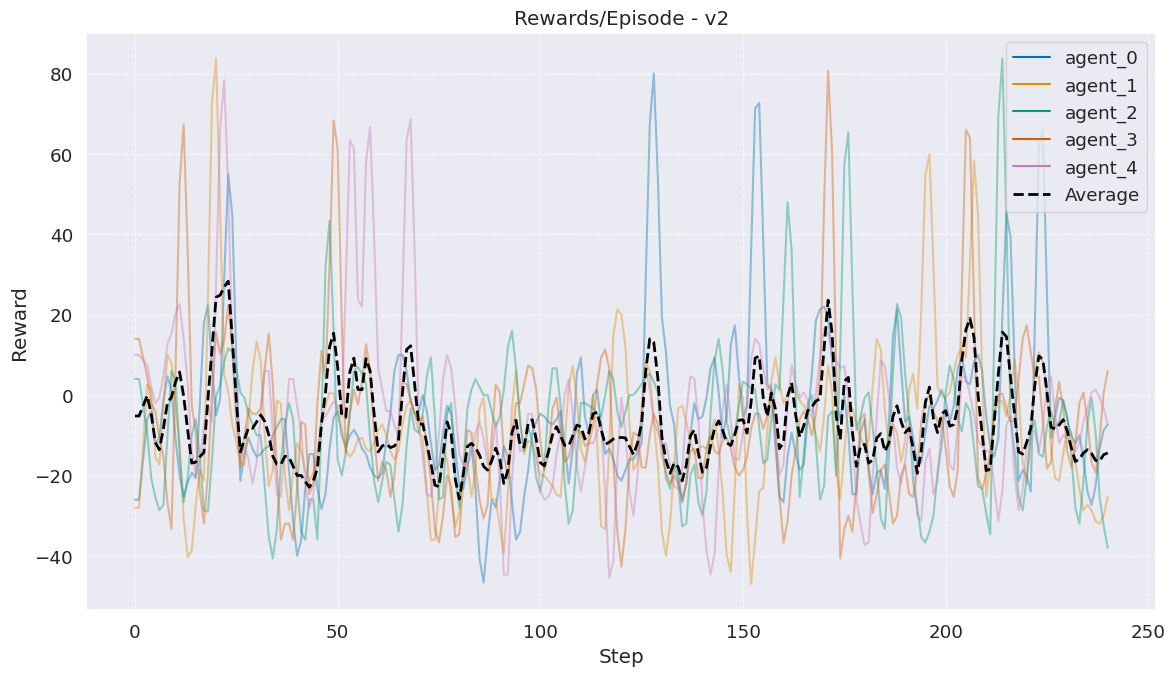

In [4]:
from plotting import plot_stats

plot_stats(eval_stats)

{'v0':      coverage  found  agent_0  agent_1  agent_2  agent_3  agent_4
 0     15.3125  False        0        0        0        0        0
 1     16.6875  False        0        0        0        0        0
 2     18.3750  False        0        0        0        0        0
 3     17.9375  False        0        0        0        0        0
 4     16.7500  False        0        0        0        0        0
 ..        ...    ...      ...      ...      ...      ...      ...
 196    5.0625  False        1        0        0        0        0
 197    8.7500  False        0        0        0        0        0
 198   10.0000  False        0        0        0        0        0
 199   11.7500  False        0        0        0        0        0
 200   10.7500  False        0        0        0        0        0
 
 [201 rows x 7 columns],
 'v1':      coverage  found  agent_0  agent_1  agent_2  agent_3  agent_4
 0     14.3750  False      -22      -22      -22      -22      -22
 1     16.2500  False  